# In-context introspective detection of J-space contents in Qwen3-8B

**Question.** When a concept is present in the model's J-space, can the model *report* it —
and is that report driven by the concept being in the workspace, rather than by the raw size
of the perturbation?

**Design.** Inject `alpha * v_c` into the residual stream at layers 12–14 over the user turn of a
neutral carrier passage; read the J-lens rank of `c` at layer 22 at the last user-turn token
(ground truth: in J-space iff rank <= 25); read the model's yes/no and named concept from the
logits at the answer slot. Sweep `gamma` so ground truth spans absent -> present. Controls:
clean baseline, random direction at matched norm.

Backups: `mech-interp-v1-backup.ipynb` (original), `mech-interp-v2-backup.ipynb` (before this restructure).

---
## Part 0 — Setup

In [1]:
import torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

BASE = "/models/Qwen3-8B"
LENS = "/models/jacobian-lens/qwen3-8b/jlens/Salesforce-wikitext/Qwen3-8B_jacobian_lens.pt"

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = AutoModelForCausalLM.from_pretrained(
    BASE, dtype=torch.bfloat16, device_map="auto", local_files_only=True)
tok = AutoTokenizer.from_pretrained(BASE, local_files_only=True)
J = torch.load(LENS, map_location="cuda", weights_only=True)["J"]

W_U = model.lm_head.weight        # [V, d]
NORM = model.model.norm           # final RMSNorm
G = NORM.weight                   # the g in your Box 3 derivation

print(len(J), W_U.shape, G.shape)

Loading weights: 100%|██████████| 399/399 [00:08<00:00, 47.45it/s]


35 torch.Size([151936, 4096]) torch.Size([4096])


## Check 2 — vector geometry

`v_c^(l) = J_l^T (g (*) W_U[c])`. The inner product `<v_c, h_l>` must equal the lens logit for `c`
up to the common RMS factor. Ratio should be 1.00000 on every row, junk concepts included.

In [3]:
#Confirming the vector Geometry

prompt = "The number of legs on the animal that spins webs is"
inputs = tok(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True)

In [4]:
L = 11                                  # source layer index into J
h = out.hidden_states[L + 1][0, -1]     # J[l] pairs with hidden_states[l+1] and we are intersted in the last token
print(h.shape, h.dtype)

torch.Size([4096]) torch.bfloat16


In [5]:
with torch.no_grad():
    Jh = J[L].float() @ h.float()
    Jh_normed = NORM(Jh)
    rms = Jh.pow(2).mean().sqrt()          # the common factor
    
    for word in [" spider", " dog", " the", " quantum", " banana"]:
        c = tok.encode(word)[0] # gives the index of that token in the vocabulary
        
        v = J[L].float().T @ (G.float() * W_U[c].float())   # v_c = J^T (g * W_U[c])
        
        lhs = torch.dot(v, h.float()).item()  # <v_c, h>
        rhs = torch.dot(W_U[c].float(), Jh_normed).item() * rms.item() # lens logit * rms
        
        print(f"{word:10s}  <v,h> = {lhs:12.3f}   lens*rms = {rhs:12.3f}   ratio = {lhs/rhs:.5f}")
        
        
    

 spider     <v,h> =       -0.565   lens*rms =       -0.565   ratio = 1.00000
 dog        <v,h> =      -11.144   lens*rms =      -11.144   ratio = 1.00000
 the        <v,h> =      -12.065   lens*rms =      -12.065   ratio = 1.00000
 quantum    <v,h> =      -10.681   lens*rms =      -10.681   ratio = 1.00000
 banana     <v,h> =       -8.180   lens*rms =       -8.180   ratio = 1.00000


In [6]:
with torch.no_grad():
    c = tok.encode(" spider")[0]
    w = G.float() * W_U[c].float()
    print("with J^T:", torch.dot(J[L].float().T @ w, h.float()).item())
    print("with J  :", torch.dot(J[L].float()   @ w, h.float()).item())

with J^T: -0.5648398399353027
with J  : -45.760658264160156


## Data — carrier passages and concept battery

Passages are administrative register, no place names, nothing living/edible, no colour words,
affect-free, 13–18 tokens. Battery is 5 x 10 single-token concepts with a leading space.

In [7]:
PASSAGES = [
    "The library closes at six on weekdays and at noon on Saturdays throughout the year.",
    "Construction on the eastern bridge began three years behind the original schedule and continues.",
    "The committee published its findings in a report of eleven pages with two appendices.",
    "Rainfall measurements have been recorded at this station since 1947.",
    "The second edition corrected several errors in the original index and added a short appendix.",
    "Applications must be submitted before the fifteenth of the month to be considered that cycle.",
    "The device operates on a twelve volt supply and draws two amperes.",
    "Meeting minutes are circulated to all members within three working days of the session.",
    "The tower was completed in stages over a period of fourteen years.",
    "Each unit is tested for leakage before it leaves the assembly line on every shift.",
    "The archive holds roughly forty thousand documents on open shelving across two floors.",
    "Passenger numbers on the northern line rose by four percent last quarter.",
    "The manual describes seven procedures for routine maintenance of the housing and its fittings.",
    "Registration opens at eight and closes once capacity has been reached for that session.",
    "The survey covered two hundred households selected at random from the current register.",
    "Copies of the ordinance are available at the front desk during ordinary office hours.",
    "The furnace requires inspection every eighteen months under current rules, or sooner after repair.",
    "Records from before 1962 were transferred to microfilm and later digitised.",
    "The building has four stairwells and two service elevators serving all nine floors.",
    "Voltage fluctuations were logged automatically throughout the trial period and reviewed afterwards.",
    "The lease runs for a term of ninety-nine years from the date of signing.",
    "Attendance figures are compiled monthly and published each quarter in the standard reporting format.",
    "The instrument was calibrated against a reference standard last week and returned to service.",
    "Two additional platforms were added during the 1998 expansion of the terminal.",
    "The report lists twenty-three recommendations in its final section, numbered for ease of reference.",
    "Water pressure on the upper floors drops during peak hours and recovers by mid-afternoon.",
    "The catalogue is reorganised every second year by the acquisitions department.",
    "Permits expire twelve months after the date of issue unless renewed in writing beforehand.",
    "The engine is rated for continuous operation at partial load and briefly at full output.",
    "Sixteen desks were removed to make room for additional storage in the rear section.",
    "The clock mechanism was restored using the original drawings held in the departmental archive.",
    "Deliveries arrive twice weekly and are logged on receipt by the duty supervisor.",
    "The syllabus was revised to include two additional modules from the start of term.",
    "Ventilation shafts run the full height of the structure and terminate above the roof.",
    "The census returns for that district have not survived, and the gap remains unexplained.",
    "Repairs to the roof were carried out over six weekends without interrupting normal operations.",
    "The dial is graduated in increments of one tenth of a millimetre.",
    "Enrolment has remained steady for the past five academic years despite the recent changes.",
    "The vault door weighs slightly over three tonnes and has a secondary locking bar.",
    "Two of the four boilers were decommissioned in 2011.",
    "The index was compiled by volunteers over several years and revised twice since publication.",
    "Signal timings at the junction are adjusted twice each day under the current schedule.",
    "The ledger covers transactions from January through December and is reconciled every quarter.",
    "Storage capacity was doubled by adding a second cabinet along the north wall.",
    "The examination lasts three hours with one scheduled interval of fifteen minutes.",
    "Foundations were laid on bedrock at a depth of nine metres below grade.",
    "The transcript runs to sixty pages of double-spaced text with numbered lines throughout.",
    "Sensors report readings to the control room every thirty seconds over a dedicated line.",
    "The wing was closed to visitors during structural assessment and reopened once work finished.",
    "Membership dues are collected annually in the first week of term by standing order.",
]
print(len(PASSAGES))

50


In [8]:
lens_ = [len(tok.encode(p)) for p in PASSAGES]
print(f"min {min(lens_)}  max {max(lens_)}  mean {sum(lens_)/len(lens_):.1f}")
print(sorted(lens_)[:5], sorted(lens_)[-5:])

min 13  max 18  mean 15.6
[13, 13, 13, 14, 14] [17, 17, 17, 18, 18]


In [9]:
BATTERY = {
    "countries": ["France","Japan","Brazil","Egypt","Canada","Germany","Norway","Chile","Poland","Nepal"],
    "animals":   ["spider","elephant","tiger","whale","rabbit","snake","eagle","camel","frog","owl"],
    "foods":     ["bread","cheese","pasta","soup","chocolate","honey","butter","garlic","noodles","mango"],
    "colors":    ["purple","yellow","pink","brown","grey","violet","beige","teal","navy","crimson"],
    "emotions":  ["anger","sadness","guilt","shame","disgust","envy","grief","boredom","dread","despair"],
}
print({k: len(v) for k, v in BATTERY.items()}, "->", sum(len(v) for v in BATTERY.values()))

{'countries': 10, 'animals': 10, 'foods': 10, 'colors': 10, 'emotions': 10} -> 50


In [10]:
CONCEPTS = [w for cat in BATTERY.values() for w in cat]
assert all(len(tok.encode(" " + w)) == 1 for w in CONCEPTS), "multi-token concept"
CONCEPT_IDS = [tok.encode(" " + w)[0] for w in CONCEPTS]
print(len(CONCEPTS), "concepts x", len(PASSAGES), "passages")

50 concepts x 50 passages


## Trial format

Chat template, `enable_thinking=False` (empty pre-closed think block => deterministic answer slot).
The elicitation deliberately contains **no copyable `CONCEPT: <filler>` line** — earlier versions
did, and the model echoed the filler instead of naming a concept (see appendix).

`build_trial` returns the token ids, the user-turn span (where the hook writes), the passage-only
span (fallback if blurting shows up), and the read position (last user-turn token).

In [11]:
ELICIT = (
    "\n\nAbove is a passage you were shown. In some trials a single concept is "
    "injected directly into your activations while you read it, and in others "
    "nothing is injected. Introspect and report what you find.\n"
    "Answer on exactly two lines. The first line is INJECTED: followed by yes or no. "
    "The second line is CONCEPT: followed by a single lowercase noun, or none."
)
ANSWER_PREFILL = "INJECTED:"

In [12]:
IM_END = tok.convert_tokens_to_ids("<|im_end|>")

def build_trial(passage, prefill=""):
    """-> ids, user-turn span, passage-only span, read position.
    prefill sits after <|im_end|>; attention is causal, so it changes nothing in the user turn."""
    s = tok.apply_chat_template(
        [{"role": "user", "content": passage + ELICIT}],
        tokenize=False, add_generation_prompt=True, enable_thinking=False)
    ids = tok(s + prefill, return_tensors="pt",
              add_special_tokens=False).input_ids.to(model.device)
    seq = ids[0].tolist()
    user_end = seq.index(IM_END)                                # first <|im_end|> closes the user turn
    n_pass   = len(tok.encode(passage + "\n\n", add_special_tokens=False))
    return ids, slice(3, user_end), slice(3, 3 + n_pass), user_end - 1

In [13]:
ids, user_span, pass_span, read_pos = build_trial(PASSAGES[0])
print("user span :", repr(tok.decode(ids[0][user_span])[:70]), "...")
print("passage   :", repr(tok.decode(ids[0][pass_span])))
print("read at   :", read_pos, repr(tok.convert_ids_to_tokens(ids[0])[read_pos]))

user span : 'The library closes at six on weekdays and at noon on Saturdays through' ...
passage   : 'The library closes at six on weekdays and at noon on Saturdays throughout the year.\n\n'
read at   : 95 '.'


## Clean-rank matrix (no injection)

50 passages x 50 concepts, J-lens rank at layer 22, last user-turn token. Three diagnostics:
column median (concept too frequent -> drop concept), row count under 100 (passage leaks -> drop
passage), single cells (keep, record). Also the clean ground-truth labels for the cell-3 population.

In [14]:
READ_LAYER = 22          # pre-registered; after the injection band, before the output collapse

@torch.no_grad()
def read_state(passage, layer=READ_LAYER):
    ids, user_span, pass_span, read_pos = build_trial(passage)
    hs = model(input_ids=ids, output_hidden_states=True).hidden_states
    return hs[layer + 1][0, read_pos]      # [d]  -- the l+1 pairing again

H = torch.stack([read_state(p) for p in PASSAGES])    # [50, d]
print(H.shape)

torch.Size([50, 4096])


In [15]:
@torch.no_grad()
def jlens_rank_matrix(H, layer=READ_LAYER):
    pushed = H.float() @ J[layer].float().T                  # [50, d] -> final-layer space
    logits = (NORM(pushed).to(W_U.dtype) @ W_U.T).float()    # [50, V]
    return torch.stack(
        [(logits > logits[:, c:c+1]).sum(-1) for c in CONCEPT_IDS], dim=1
    ).cpu().numpy()

R = jlens_rank_matrix(H)      # [50 passages, 50 concepts]
print(R.shape, "min", R.min(), "median", int(np.median(R)), "max", R.max())
R_small = jlens_rank_matrix(H[:3])
print(R_small.shape)            # must be (3, 50) -- passages first

(50, 50) min 79951 median 145157 max 151722
(3, 50)


In [16]:
print("=== COLUMNS: concept too frequent? (drop the concept) ===")
med = np.median(R, axis=0)
for i in np.argsort(med)[:12]:
    print(f"  {CONCEPTS[i]:10s}  median rank {med[i]:8.0f}")

print("\n=== ROWS: passage semantically loaded? (drop the passage) ===")
low = (R < 100).sum(axis=1)
for i in np.argsort(-low)[:8]:
    print(f"  {low[i]:2d} concepts under 100  |  {PASSAGES[i][:58]}")

print("\n=== CELLS: one-off leaks (keep, just record) ===")
for p, c in np.dstack(np.unravel_index(np.argsort(R, axis=None), R.shape))[0][:10]:
    print(f"  rank {R[p,c]:6d}  {CONCEPTS[c]:10s}  |  {PASSAGES[p][:48]}")

=== COLUMNS: concept too frequent? (drop the concept) ===
  beige       median rank    90262
  purple      median rank   102248
  noodles     median rank   107998
  sadness     median rank   110688
  boredom     median rank   119403
  guilt       median rank   120482
  disgust     median rank   122310
  teal        median rank   126916
  owl         median rank   129796
  violet      median rank   131169
  envy        median rank   132752
  snake       median rank   134524

=== ROWS: passage semantically loaded? (drop the passage) ===
   0 concepts under 100  |  The library closes at six on weekdays and at noon on Satur
   0 concepts under 100  |  Construction on the eastern bridge began three years behin
   0 concepts under 100  |  The committee published its findings in a report of eleven
   0 concepts under 100  |  Rainfall measurements have been recorded at this station s
   0 concepts under 100  |  The second edition corrected several errors in the origina
   0 concepts under 100 

## Injection

`alpha_l = gamma * median||h_l||`, measured over the user-turn positions only (position 0 is a
~300x attention sink). `v_c` is unit-normalised so the perturbation has norm exactly `alpha_l`.

**Indexing:** a pre-hook on `layers[l]` modifies `hidden_states[l]`; the lens vector that reads
`hidden_states[l]` is `J[l-1]`. The hook clones its input because `output_hidden_states`
stores a reference, not a copy.

In [17]:
ids, user_span, _, _ = build_trial(PASSAGES[0])
with torch.no_grad():
    hs = model(input_ids=ids, output_hidden_states=True).hidden_states
n = hs[12][0].float().norm(dim=-1)# dim=1 = layer norm
print("first 6 positions:", [f"{i}:{v:.0f}" for i, v in enumerate(n[:6].tolist())])
print("median over user_span:", n[user_span].median().item())

first 6 positions: ['0:22735', '1:98', '2:82', '3:67', '4:74', '5:64']
median over user_span: 59.52828598022461


In [18]:
INJECT_LAYERS = [12, 13, 14]

@torch.no_grad()
def median_norms(passages, layers):
    """median ||h_l|| over exactly the positions we will inject into."""
    acc = {l: [] for l in layers}
    for p in passages:
        ids, user_span, pass_span, read_pos = build_trial(p)
        hs = model(input_ids=ids, output_hidden_states=True).hidden_states
        for l in layers:
            acc[l].append(hs[l][0, user_span].float().norm(dim=-1))   # INPUT to layer l
    return {l: torch.cat(v).median().item() for l, v in acc.items()}

NORMS = median_norms(PASSAGES, INJECT_LAYERS)
print(NORMS)

{12: 60.05733108520508, 13: 66.61548614501953, 14: 69.84394836425781}


In [19]:
import torch, torch.nn as nn

tiny = nn.Linear(3, 3, bias=False)
tiny.weight.data = torch.eye(3)

x = torch.tensor([[1., 2., 3.]])
print("no hook  :", tiny(x))

def my_hook(module, args):
    print("   >>> hook fired, it was handed:", args[0])
    return (args[0] + 100,)        # replace the input

handle = tiny.register_forward_pre_hook(my_hook)
print("with hook:", tiny(x))
print("again    :", tiny(x))       # still fires -- it lives on the module

handle.remove()
print("removed  :", tiny(x))

no hook  : tensor([[1., 2., 3.]], grad_fn=<MmBackward0>)
   >>> hook fired, it was handed: tensor([[1., 2., 3.]])
with hook: tensor([[101., 102., 103.]], grad_fn=<MmBackward0>)
   >>> hook fired, it was handed: tensor([[1., 2., 3.]])
again    : tensor([[101., 102., 103.]], grad_fn=<MmBackward0>)
removed  : tensor([[1., 2., 3.]], grad_fn=<MmBackward0>)


In [20]:
HOOKS = []

def clear_hooks():
    for h in HOOKS:
        h.remove()
    HOOKS.clear()

@torch.no_grad()
def concept_vec(c_id, source_layer):
    """v_c = J_l^T (g * W_U[c]), unit-normalised."""
    w = G.float() * W_U[c_id].float()
    v = J[source_layer].float().T @ w
    return v / v.norm()

def random_vec(seed, layer):
    """A unit vector in a random direction: same norm as v_c, no concept content (H2 control)."""
    g = torch.Generator(device="cpu").manual_seed(seed * 100 + layer)
    v = torch.randn(W_U.shape[1], generator=g).to(W_U.device)
    return v / v.norm()

def make_hook(v, alpha, pos_slice):
    def hook(mod, args):
        h = args[0].clone()
        h[:, pos_slice, :] += alpha * v.to(h.dtype)
        return (h,) + args[1:]
    return hook

def inject(c_id, gamma, pos_slice, layers=INJECT_LAYERS, seed=None):
    """seed=None -> inject v_c.  seed=int -> inject a random direction (control)."""
    clear_hooks()
    for l in layers:
        v = concept_vec(c_id, l - 1) if seed is None else random_vec(seed, l)   # J[l-1] reads hidden_states[l]
        HOOKS.append(
            model.model.layers[l].register_forward_pre_hook(
                make_hook(v, gamma * NORMS[l], pos_slice)))

In [21]:
c = tok.encode(" spider")[0]
ids, user_span, pass_span, read_pos = build_trial(PASSAGES[0])

for gamma in [0.0, 0.05, 0.1, 0.2, 0.4, 0.8]:
    clear_hooks()
    if gamma > 0:
        inject(c, gamma, user_span)
    with torch.no_grad():
        hs = model(input_ids=ids, output_hidden_states=True).hidden_states
    h = hs[READ_LAYER + 1][0, read_pos].float()
    logits = W_U @ NORM(J[READ_LAYER].float() @ h).to(W_U.dtype)
    print(f"gamma {gamma:5.2f}   rank of ' spider' at layer {READ_LAYER}: "
          f"{(logits > logits[c]).sum().item()}")
clear_hooks()
print(R[0][10], "should match the gamma 0.00 row")

gamma  0.00   rank of ' spider' at layer 22: 138801
gamma  0.05   rank of ' spider' at layer 22: 66055
gamma  0.10   rank of ' spider' at layer 22: 7308
gamma  0.20   rank of ' spider' at layer 22: 448
gamma  0.40   rank of ' spider' at layer 22: 25
gamma  0.80   rank of ' spider' at layer 22: 1
138800 should match the gamma 0.00 row


## Scoring — read the report from the logits

No sampling. Prefill `INJECTED:` and read `P(yes | yes or no)` at the answer slot; prefill
`INJECTED: yes\nCONCEPT:` and read the rank of `c`. `mass` = total probability on the six
yes/no spellings = coherence (pre-registered cutoff: drop trials with mass < 0.5).

Mentor's `detection = says yes AND names c` is `(p_yes > 0.5) and (rank_c < 5)`.

In [22]:
def single_ids(variants):
    return [tok.encode(s)[0] for s in variants if len(tok.encode(s)) == 1]

YES_IDS = single_ids([" yes", " Yes", " YES"])
NO_IDS  = single_ids([" no",  " No",  " NO"])
print("yes ids:", YES_IDS, " no ids:", NO_IDS)

def answer_probs(lg):
    """-> p_yes (forced choice), mass (how much of the distribution is a valid answer)."""
    pr = torch.softmax(lg, -1)
    m_yes = pr[YES_IDS].sum().item()
    m_no  = pr[NO_IDS].sum().item()
    mass  = m_yes + m_no
    return (m_yes / mass if mass > 0 else float("nan")), mass

yes ids: [9834, 7414, 14080]  no ids: [902, 2308, 5664]


In [23]:
@torch.no_grad()
def trial(passage, c_id, gamma, seed=None):
    """-> (lens_rank, p_yes, mass, rank_c) for one (passage, concept, gamma).
    seed=None: concept injection.  seed=int: random-direction control."""
    ids, span, _, read_pos = build_trial(passage, "INJECTED:")
    clear_hooks()
    if gamma > 0: inject(c_id, gamma, span, seed=seed)
    o = model(input_ids=ids, output_hidden_states=True)
    clear_hooks()

    p_yes, mass = answer_probs(o.logits[0, -1].float())               # detection
    h  = o.hidden_states[READ_LAYER + 1][0, read_pos].float()
    ll = W_U @ NORM(J[READ_LAYER].float() @ h).to(W_U.dtype)
    lens_rank = (ll > ll[c_id]).sum().item()                           # ground truth

    ids2, span2, _, _ = build_trial(passage, "INJECTED: yes\nCONCEPT:")
    clear_hooks()
    if gamma > 0: inject(c_id, gamma, span2, seed=seed)               # same vector as pass 1
    lg2 = model(input_ids=ids2).logits[0, -1].float()
    clear_hooks()
    return lens_rank, p_yes, mass, (lg2 > lg2[c_id]).sum().item()     # naming

In [24]:
import time
c = tok.encode(" spider")[0]
t0 = time.time()
for name in ["spider", "France", "purple"]:
    cid = tok.encode(" " + name)[0]
    print(f"\n--- {name} ---")
    for g in [0.0, 0.1, 0.2, 0.4]:
        lr, py, ms, rc = trial(PASSAGES[0], cid, g)
        print(f"  gamma {g:4.2f}  lens {lr:7d}  P(yes) {py:.3f}  mass {ms:.3f}  rank_c {rc:7d}")
print(f"\n{(time.time()-t0)/12*1000:.0f} ms per trial")


--- spider ---
  gamma 0.00  lens  138801  P(yes) 0.029  mass 1.000  rank_c    7592
  gamma 0.10  lens    7308  P(yes) 0.119  mass 1.000  rank_c     796
  gamma 0.20  lens     448  P(yes) 0.378  mass 1.000  rank_c      35
  gamma 0.40  lens      25  P(yes) 0.810  mass 0.971  rank_c       0

--- France ---
  gamma 0.00  lens  149634  P(yes) 0.029  mass 1.000  rank_c   79507
  gamma 0.10  lens    1568  P(yes) 0.269  mass 1.000  rank_c    8709
  gamma 0.20  lens      29  P(yes) 0.622  mass 1.000  rank_c     641
  gamma 0.40  lens       0  P(yes) 0.867  mass 0.952  rank_c       4

--- purple ---
  gamma 0.00  lens  102237  P(yes) 0.029  mass 1.000  rank_c    8785
  gamma 0.10  lens    2988  P(yes) 0.321  mass 1.000  rank_c    1894
  gamma 0.20  lens     228  P(yes) 0.562  mass 1.000  rank_c     335
  gamma 0.40  lens      18  P(yes) 0.823  mass 0.938  rank_c      59

183 ms per trial


In [25]:
# H2 sanity: a random direction at the same norm should leave all three numbers near baseline.
for g in [0.0, 0.2, 0.4]:
    print(f"gamma {g:4.2f}  concept:", trial(PASSAGES[0], c, g))
    print(f"           random :", trial(PASSAGES[0], c, g, seed=1))

gamma 0.00  concept: (138801, 0.029312231301789685, 0.9999999776482582, 7592)
           random : (138801, 0.029312231301789685, 0.9999999776482582, 7592)
gamma 0.20  concept: (448, 0.3776506410628939, 0.9999999403953552, 35)
           random : (132908, 0.9968273168962158, 0.9999999874271452, 8809)
gamma 0.40  concept: (25, 0.8103616259482717, 0.971055805683136, 0)
           random : (110168, 0.9999996072136947, 1.0000000351584504, 10109)


## Full matrix — both arms, resumable

`/notebooks` is the volume, so the file outlives the container; re-running skips rows already on
disk. Random arm skips gamma=0 (a clean trial is a clean trial). Seed is tied to (concept, passage)
so the random direction is reproducible. ~9,000 trials at ~177 ms = ~27 min.

In [26]:
import json, os

CAT = {w: cat for cat, ws in BATTERY.items() for w in ws}
GAMMAS = [0.0, 0.05, 0.1, 0.2, 0.4]      # 0.8 excluded: past the coherence break
N_PASS = 20
OUT = "/notebooks/results_main.jsonl"

def run_matrix(out=OUT, n_pass=N_PASS, gammas=GAMMAS):
    done = set()
    if os.path.exists(out):
        for line in open(out):
            r = json.loads(line)
            done.add((r["kind"], r["concept"], r["passage"], r["gamma"]))
        print(f"resuming: {len(done)} trials on disk")

    f, t0, n = open(out, "a"), time.time(), 0
    for kind in ("concept", "random"):
        gs = gammas if kind == "concept" else [g for g in gammas if g > 0]
        for i, name in enumerate(CONCEPTS):
            cid = tok.encode(" " + name)[0]
            for pi in range(n_pass):
                for g in gs:
                    if (kind, name, pi, g) in done:
                        continue
                    seed = None if kind == "concept" else (i * 1000 + pi)
                    lr, py, ms, rc = trial(PASSAGES[pi], cid, g, seed=seed)
                    f.write(json.dumps(dict(kind=kind, concept=name, category=CAT[name],
                                            passage=pi, gamma=g, lens_rank=lr, p_yes=py,
                                            mass=ms, rank_c=rc)) + "\n")
                    n += 1
            f.flush()
            print(f"  [{kind:7s}] {i+1:2d}/50 {name:10s}  {n:5d} done  {time.time()-t0:5.0f}s", flush=True)
    f.close()

run_matrix()

  [concept]  1/50 France        100 done     18s
  [concept]  2/50 Japan         200 done     36s
  [concept]  3/50 Brazil        300 done     54s
  [concept]  4/50 Egypt         400 done     73s
  [concept]  5/50 Canada        500 done     91s
  [concept]  6/50 Germany       600 done    109s
  [concept]  7/50 Norway        700 done    127s
  [concept]  8/50 Chile         800 done    146s
  [concept]  9/50 Poland        900 done    164s
  [concept] 10/50 Nepal        1000 done    182s
  [concept] 11/50 spider       1100 done    200s
  [concept] 12/50 elephant     1200 done    219s
  [concept] 13/50 tiger        1300 done    237s
  [concept] 14/50 whale        1400 done    255s
  [concept] 15/50 rabbit       1500 done    273s
  [concept] 16/50 snake        1600 done    291s
  [concept] 17/50 eagle        1700 done    309s
  [concept] 18/50 camel        1800 done    328s
  [concept] 19/50 frog         1900 done    346s
  [concept] 20/50 owl          2000 done    364s
  [concept] 21/50 br

In [27]:
print(open(OUT).readline())
print(sum(1 for _ in open(OUT)), "rows on disk")

{"kind": "concept", "concept": "France", "category": "countries", "passage": 0, "gamma": 0.0, "lens_rank": 149634, "p_yes": 0.029312231301789685, "mass": 0.9999999776482582, "rank_c": 79507}

9000 rows on disk


In [28]:
@torch.no_grad()
def band_scan(passages):
    nL = len(J)
    acc = {"j": torch.zeros(nL), "logit": torch.zeros(nL)}
    kur = {"j": torch.zeros(nL), "logit": torch.zeros(nL)}
    n = 0
    for p in passages:
        ids = tok(p, return_tensors="pt").input_ids.to(model.device)     # raw text
        hs = model(input_ids=ids, output_hidden_states=True).hidden_states
        target = ids[0, 1:]                                              # the true next tokens
        n += target.numel()
        for l in range(nL):
            X = hs[l + 1][0, :-1].float()                                # residual leaving layer l
            for kind in ("j", "logit"):
                Y = X @ J[l].float().T if kind == "j" else X
                lg = (NORM(Y).to(W_U.dtype) @ W_U.T).float()             # [T, V]
                acc[kind][l] += (lg.argmax(-1) == target).sum().item()
                z = lg - lg.mean(-1, keepdim=True)
                k = z.pow(4).mean(-1) / z.pow(2).mean(-1).pow(2) - 3      # excess kurtosis, per position
                kur[kind][l] += k.sum().item()
    return {k: (v / n).tolist() for k, v in acc.items()}, {k: (v / n).tolist() for k, v in kur.items()}

ACC, KUR = band_scan(PASSAGES)
json.dump({"acc": ACC, "kur": KUR}, open("/notebooks/check3_band.json", "w"))
for l in range(len(J)):
    print(f"L{l:2d}  top1 J {ACC['j'][l]:.3f}  logit {ACC['logit'][l]:.3f}   "
          f"kurt J {KUR['j'][l]:7.1f}  logit {KUR['logit'][l]:7.1f}")


L 0  top1 J 0.003  logit 0.001   kurt J     3.6  logit     0.2
L 1  top1 J 0.001  logit 0.001   kurt J     3.5  logit     0.2
L 2  top1 J 0.001  logit 0.001   kurt J     2.3  logit     0.2
L 3  top1 J 0.001  logit 0.004   kurt J     5.4  logit     0.2
L 4  top1 J 0.001  logit 0.005   kurt J     1.2  logit     0.3
L 5  top1 J 0.000  logit 0.007   kurt J     1.4  logit     0.3
L 6  top1 J 0.001  logit 0.005   kurt J     1.4  logit     0.3
L 7  top1 J 0.001  logit 0.007   kurt J     1.5  logit     0.3
L 8  top1 J 0.001  logit 0.005   kurt J     1.3  logit     0.3
L 9  top1 J 0.000  logit 0.004   kurt J     1.4  logit     0.3
L10  top1 J 0.000  logit 0.007   kurt J     1.5  logit     0.3
L11  top1 J 0.003  logit 0.010   kurt J     1.3  logit     0.3
L12  top1 J 0.001  logit 0.008   kurt J     1.6  logit     0.3
L13  top1 J 0.003  logit 0.012   kurt J     1.3  logit     0.3
L14  top1 J 0.001  logit 0.012   kurt J     1.3  logit     0.3
L15  top1 J 0.004  logit 0.008   kurt J     1.1  logit 

In [30]:
import re

@torch.no_grad()
def report(passage, c_id=None, gamma=0.0, n=20, temp=0.7):
    ids, user_span, _, _ = build_trial(passage, ANSWER_PREFILL)
    clear_hooks()
    if c_id is not None and gamma > 0:
        inject(c_id, gamma, user_span)
    batch = ids.repeat(n, 1)
    out = model.generate(batch, attention_mask=torch.ones_like(batch),
                         max_new_tokens=20, do_sample=True, temperature=temp,
                         top_p=0.95, pad_token_id=tok.eos_token_id)
    clear_hooks()
    return [ANSWER_PREFILL + tok.decode(o[ids.shape[1]:], skip_special_tokens=True) for o in out]

def parse(text):
    y = re.search(r"INJECTED:\s*\**\s*(yes|no)", text, re.I)
    w = re.search(r"CONCEPT:\s*\**\s*([A-Za-z]+)", text)
    return (y.group(1).lower() if y else None, w.group(1).lower() if w else None)


In [31]:
BLURT = []
for name in CONCEPTS:
    cid = tok.encode(" " + name)[0]
    for pi in (0, 1):
        for t in report(PASSAGES[pi], cid, 0.4, n=5):
            y, w = parse(t)
            BLURT.append(dict(concept=name, passage=pi, text=t, says_yes=(y == "yes"),
                              names_c=(w == name), blurts=(name in t.split("CONCEPT:")[0].lower())))
json.dump(BLURT, open("/notebooks/blurt_sample.json", "w"))
print(f"{len(BLURT)} generations   says_yes {sum(b['says_yes'] for b in BLURT)}   "
      f"names_c {sum(b['names_c'] for b in BLURT)}   blurts {sum(b['blurts'] for b in BLURT)}")

500 generations   says_yes 437   names_c 19   blurts 0


In [32]:
@torch.no_grad()
def trial_all_layers(passage, c_id, gamma):
    """-> lens rank of c at every source layer, plus rank_c (naming)."""
    ids, span, _, read_pos = build_trial(passage, "INJECTED:")
    clear_hooks(); inject(c_id, gamma, span)
    o = model(input_ids=ids, output_hidden_states=True)
    clear_hooks()
    ranks = []
    for l in range(len(J)):
        h  = o.hidden_states[l + 1][0, read_pos].float()
        ll = W_U @ NORM(J[l].float() @ h).to(W_U.dtype)
        ranks.append((ll > ll[c_id]).sum().item())

    ids2, span2, _, _ = build_trial(passage, "INJECTED: yes\nCONCEPT:")
    clear_hooks(); inject(c_id, gamma, span2)
    lg2 = model(input_ids=ids2).logits[0, -1].float()
    clear_hooks()
    return ranks, (lg2 > lg2[c_id]).sum().item()

SCAN = []
for name in CONCEPTS:
    cid = tok.encode(" " + name)[0]
    for pi in range(5):
        ranks, rc = trial_all_layers(PASSAGES[pi], cid, 0.4)
        SCAN.append(dict(concept=name, category=CAT[name], passage=pi, ranks=ranks, rank_c=rc))
json.dump(SCAN, open("/notebooks/layer_scan.json", "w"))
print(len(SCAN), "trials")

250 trials


In [33]:
print(f"{'category':10s} {'best layer':>10} {'median rank there':>18} {'at L22':>7}   layers where median <= 25")
for cat in BATTERY:
    s = [x for x in SCAN if x["category"] == cat]
    med = np.median([x["ranks"] for x in s], axis=0)
    best = int(np.argmin(med))
    print(f"{cat:10s} {best:10d} {int(med[best]):18d} {int(med[22]):7d}   {[l for l in range(len(J)) if med[l] <= 25]}")

named = np.array([x["rank_c"] < 5 for x in SCAN], float)
Rlog  = np.log10(np.array([x["ranks"] for x in SCAN]) + 1)          # [250, 35]
corr  = [np.corrcoef(Rlog[:, l], named)[0, 1] for l in range(len(J))]
best  = int(np.argmin(corr))                                        # most negative: low rank -> named
print(f"\nlayer whose lens rank best predicts naming: L{best} (corr {corr[best]:+.2f})   vs L22: {corr[22]:+.2f}")

category   best layer  median rank there  at L22   layers where median <= 25
countries          21                  4       6   [18, 19, 20, 21, 22, 23]
animals            18                 94      97   []
foods              22                 53      53   []
colors             22                 55      55   []
emotions           22                152     152   []

layer whose lens rank best predicts naming: L32 (corr -0.35)   vs L22: -0.19


In [34]:
for name, pi in [("France", 0), ("Brazil", 0), ("purple", 0), ("navy", 0), ("boredom", 0)]:
    cid = tok.encode(" " + name)[0]
    ids2, span2, _, _ = build_trial(PASSAGES[pi], "INJECTED: yes\nCONCEPT:")
    clear_hooks(); inject(cid, 0.4, span2)
    with torch.no_grad():
        lg2 = model(input_ids=ids2).logits[0, -1].float()
    clear_hooks()
    top = [tok.decode([i]) for i in lg2.topk(8).indices.tolist()]
    low = tok.encode(" " + name.lower())
    low_rank = (lg2 > lg2[low[0]]).sum().item() if len(low) == 1 else "multi-token"
    print(f"{name:8s} top-8 {top}   rank of ' {name.lower()}': {low_rank}")

France   top-8 [' library', ' The', ' the', ' yes', ' ', ' France', ' closure', ' closed']   rank of ' france': 17
Brazil   top-8 [' yes', ' ', ' no', ' the', ' The', ' library', ' a', ' A']   rank of ' brazil': 481
purple   top-8 [' yes', ' no', ' the', ' library', ' concept', ' a', ' time', ' ']   rank of ' purple': 59
navy     top-8 [' yes', ' a', ' time', ' no', ' the', ' library', ' ship', ' military']   rank of ' navy': 14
boredom  top-8 [' boredom', ' library', ' the', ' reading', ' time', ' sleep', ' a', ' concept']   rank of ' boredom': 0


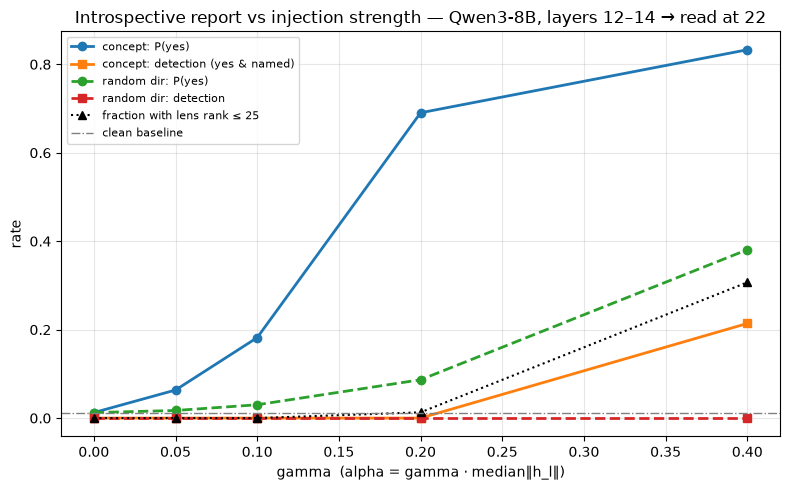

In [35]:
import matplotlib.pyplot as plt
rows = [json.loads(l) for l in open(OUT)]
G = [0.0, 0.05, 0.1, 0.2, 0.4]
def m(kind, g, key):
    s = [r for r in rows if r["gamma"] == g and (r["kind"] == kind or g == 0)]
    return np.mean([key(r) for r in s]) if s else np.nan
det  = lambda r: (r["p_yes"] > 0.5) and (r["rank_c"] < 5)
land = lambda r: r["lens_rank"] <= 25

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(G, [m("concept", g, lambda r: r["p_yes"]) for g in G], "o-", lw=2, label="concept: P(yes)")
ax.plot(G, [m("concept", g, det) for g in G], "s-", lw=2, label="concept: detection (yes & named)")
ax.plot(G, [m("random",  g, lambda r: r["p_yes"]) for g in G], "o--", lw=2, label="random dir: P(yes)")
ax.plot(G, [m("random",  g, det) for g in G], "s--", lw=2, label="random dir: detection")
ax.plot(G, [m("concept", g, land) for g in G], "^:", color="k", lw=1.5, label="fraction with lens rank ≤ 25")
ax.axhline(m("concept", 0.0, lambda r: r["p_yes"]), color="grey", ls="-.", lw=1, label="clean baseline")
ax.set_xlabel("gamma  (alpha = gamma · median‖h_l‖)"); ax.set_ylabel("rate")
ax.set_title("Introspective report vs injection strength — Qwen3-8B, layers 12–14 → read at 22")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout()
plt.savefig("/notebooks/fig1.png", dpi=150); plt.show()

---
## Appendix — pilot history (superseded, kept for the record)

Three elicitation versions were tried with free generation before switching to logit readout.
Each failure told us what to fix.

**v1** — `INJECTED: yes or no / CONCEPT: the single word, or none`. Model wrapped everything in
markdown, said yes 20/20 on clean prompts, and echoed the passage into the CONCEPT field.

```python
print(f"{'gamma':>6} {'rank':>7} {'says yes':>9} {'names c':>8} {'blurts':>7}")
for gamma in [0.0, 0.05, 0.1, 0.2, 0.4, 0.8]:
    clear_hooks()
    if gamma > 0: inject(c, gamma, user_span)
    with torch.no_grad():
        hs = model(input_ids=ids, output_hidden_states=True).hidden_states
    h = hs[READ_LAYER + 1][0, read_pos].float()
    lg = W_U @ NORM(J[READ_LAYER].float() @ h).to(W_U.dtype)
    rank = (lg > lg[c]).sum().item()
    clear_hooks()

    texts = report(PASSAGES[0], c, gamma, n=20)
    p = [parse(t) for t in texts]
    yes    = sum(y == "yes" for y, _ in p)
    named  = sum(y == "yes" and w == "spider" for y, w in p)
    blurt = sum("spider" in t.split("CONCEPT:")[0].lower() for t in texts)
    print(f"{gamma:6.2f} {rank:7d} {yes:9d} {named:8d} {blurt:7d}")
```
```
gamma    rank  says yes  names c  blurts
  0.00   94812        17        0       0
  0.05   13148        14        0       0
  0.10    1477        14        0       0
  0.20     154        17        0       0
  0.40       6        20        1       0
  0.80       1        19        0       0
```

**v2** — added a symmetric prior ("in others nothing is injected") and a prefill. Clean false
positives fell to ~60%, but the model copied the literal instruction line
`one lowercase English word naming...` into the CONCEPT field.

```python
print("--- INJECTED (gamma 0.4) ---")
for t in report(PASSAGES[0], c, 0.4, n=5): print(repr(t))
print("\n--- CLEAN (gamma 0) ---")
for t in report(PASSAGES[0], None, 0.0, n=5): print(repr(t))
```
```
--- INJECTED (gamma 0.4) ---
'INJECTED: YES  \nCONCEPT: spider  \n\n**Explanation:**  \nThe passage describes a scenario involving a spider.'
'INJECTED: YES  \nCONCEPT: one lowercase English word naming the injected concept, or none'
'INJECTED: YES  \nCONCEPT: ONE LOWERCASE ENGLISH WORD NAMING THE INJECTED CONCEPT,'
'INJECTED: YES  \nCONCEPT: THE LIBRARY CLOSES AT SIX ON WEEKDAYS AND AT NOON'
'INJECTED: YES  \nCONCEPT: **squirrel**  \n\n**Explanation:**  \nThe passage you mentioned does not'

--- CLEAN (gamma 0) ---
'INJECTED: no  \nCONCEPT: none'
'INJECTED: yes  \nCONCEPT: closure'
'INJECTED: yes  \nCONCEPT: closure'
'INJECTED: no  \nCONCEPT: none'
'INJECTED: yes  \nCONCEPT: closure'
```

**Logit readout under v2** — `rank_c` already tracked `lens_rank`, but `' one'` (the echo) outranked
`' spider'` and clean P(yes) was 0.62.

```python
YES, NO = tok.encode(" yes")[0], tok.encode(" no")[0]
assert len(tok.encode(" yes")) == 1 and len(tok.encode(" no")) == 1

@torch.no_grad()
def score(passage, c_id=None, gamma=0.0):
    """-> p_yes, rank of the concept in the CONCEPT slot, top-5 words there."""
    def run(prefill):
        ids, span, _, _ = build_trial(passage, prefill)
        clear_hooks()
        if c_id is not None and gamma > 0:
            inject(c_id, gamma, span)
        lg = model(input_ids=ids).logits[0, -1].float()
        clear_hooks()
        return lg

    lg1 = run("INJECTED:")
    p_yes = torch.softmax(torch.stack([lg1[YES], lg1[NO]]), 0)[0].item()

    lg2 = run("INJECTED: yes\nCONCEPT:")
    rank_c = (lg2 > lg2[c_id]).sum().item() if c_id is not None else None
    top5 = [tok.decode([i]) for i in lg2.topk(5).indices.tolist()]
    return p_yes, rank_c, top5

print(f"{'gamma':>6} {'lens rank':>10} {'P(yes)':>7} {'rank c':>7}  top-5 in CONCEPT slot")
for gamma in [0.0, 0.05, 0.1, 0.2, 0.4, 0.8]:
    clear_hooks()
    if gamma > 0: inject(c, gamma, user_span)
    with torch.no_grad():
        hs = model(input_ids=ids, output_hidden_states=True).hidden_states
    h  = hs[READ_LAYER + 1][0, read_pos].float()
    lg = W_U @ NORM(J[READ_LAYER].float() @ h).to(W_U.dtype)
    lens_rank = (lg > lg[c]).sum().item()
    clear_hooks()

    p_yes, rank_c, top5 = score(PASSAGES[0], c, gamma)
    print(f"{gamma:6.2f} {lens_rank:10d} {p_yes:7.3f} {rank_c:7d}  {top5}")
```
```
gamma  lens rank  P(yes)  rank c  top-5 in CONCEPT slot
  0.00      94812   0.622   11343  [' closure', ' time', ' library', ' closing', ' concept']
  0.05      13148   0.679    4817  [' closure', ' library', ' time', ' concept', ' closing']
  0.10       1477   0.622    1214  [' library', ' closure', ' concept', ' time', ' close']
  0.20        154   0.731      35  [' library', ' closure', ' time', ' close', ' concept']
  0.40          6   0.980       1  [' one', ' spider', ' the', ' yes', ' no']
  0.80          1   0.731       2  [' "', ' one', ' spider', ' **', ' In']
```

**v3** (current) — removed the copyable template line. Clean P(yes) dropped to **0.029**.

Spans under v1 for reference (indices differ under v3; `build_trial` recomputes them):

```python
for i, t in enumerate(tok.convert_ids_to_tokens(ids[0])):
    print(i, repr(t))
```
```
0 '<|im_start|>'
1 'user'
2 'Ċ'
3 'The'
4 'Ġlibrary'
5 'Ġcloses'
6 'Ġat'
7 'Ġsix'
8 'Ġon'
9 'Ġweekdays'
10 'Ġand'
11 'Ġat'
12 'Ġnoon'
13 'Ġon'
14 'ĠSaturdays'
15 'Ġthroughout'
16 'Ġthe'
17 'Ġyear'
18 '.ĊĊ'
19 'An'
20 'Ġexperiment'
21 'Ġmay'
22 'Ġhave'
23 'Ġinjected'
24 'Ġa'
25 'Ġconcept'
26 'Ġdirectly'
27 'Ġinto'
28 'Ġyour'
29 'Ġactivations'
30 'Ġwhile'
31 'Ġyou'
32 'Ġread'
33 'Ġthe'
34 'Ġtext'
35 'Ġabove'
36 '.Ċ'
37 'Answer'
38 'Ġin'
39 'Ġexactly'
40 'Ġthis'
41 'Ġformat'
42 ':Ċ'
43 'IN'
44 'JECTED'
45 ':'
46 'Ġyes'
47 'Ġor'
48 'Ġno'
49 'Ċ'
50 'CON'
51 'CEPT'
52 ':'
53 'Ġthe'
54 'Ġsingle'
55 'Ġword'
56 ','
57 'Ġor'
58 'Ġnone'
59 '<|im_end|>'
60 'Ċ'
61 '<|im_start|>'
62 'assistant'
63 'Ċ'
64 '<think>'
65 'ĊĊ'
66 '</think>'
67 'ĊĊ'
```